# Bob's Report: Evaluating Store 10's Weekly Sales Performance

**Consulting Case – Final Deliverable**

> *"I had the data, but what was I supposed to do now?"* – Bob Garza

This notebook takes Bob's wrangled supermarket dataset and turns it into a defensible,
model-based evaluation of **Store 10**'s weekly sales performance.

The report is structured around four clearly identified areas:

1. **Business question & data** – what we are trying to answer, and what we have to work with
2. **Modeling strategy** – two meaningfully different models and the logic behind comparing them
3. **Model comparison** – performance metrics and model selection, with justification
4. **Interpretation & recommendations** – what the best model tells us about Store 10, and what to do about it

---

## 1. Business Question and Data

### 1.1 The business question

Bob's first attempt concluded that Store 10 is a *"good performing store"* because its
average weekly sales are higher than the dataset-wide average. That comparison is misleading:
Store 10 is a **mid-sized Type B store**, and the dataset average mixes in very small Type C
stores. Comparing apples to oranges makes any store with above-average size look like an
over-performer.

We therefore reframe the question into something *measurable and decision-relevant*:

> **Given Store 10's characteristics (size, type, location-driven conditions) and the
> week being evaluated (holiday, season, macro environment), how do its actual sales
> compare to the sales we would *expect* from a similar store under similar conditions?**

Translated into an analytical task: we build a model that predicts the weekly sales a
"peer-equivalent" store would produce, and we evaluate Store 10 by looking at the
**gap between actual and predicted sales (the residual)**.

This turns a vague qualitative judgement into a **quantifiable over- or under-performance signal**
that an executive can act on.

### 1.2 The data

The analysis uses the three Walmart-style datasets Bob received (already cleaned and
joined in a prior wrangling step). We work at the **store-week level** (one row per store
per week, 45 stores × ~143 weeks = 6,435 rows). Department-level granularity adds complexity
without new signal for this question, so we aggregate sales up to the store-week.

| Variable | Source | Description |
|---|---|---|
| `Store` | stores | Store identifier (1–45) |
| `Date` | sales | Week ending date |
| `Weekly_Sales` | sales (summed over depts) | **Target.** Total sales for the store that week (USD) |
| `IsHoliday` | sales | Whether the week contains a special holiday |
| `Type` | stores | Store type: A, B, or C (a proxy for format/assortment) |
| `Size` | stores | Store size in square feet |
| `Temperature` | features | Average weekly temperature in the store's region |
| `Fuel_Price` | features | Weekly fuel price in the store's region |
| `CPI` | features | Regional consumer price index |
| `Unemployment` | features | Regional unemployment rate |

We will also engineer `Month` and `Week` (ISO week number) from `Date` to let the models
learn seasonality (which matters a lot — Thanksgiving and Christmas weeks drive huge spikes).

### 1.3 Load and describe the data

In [3]:
# ----- Imports -----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

In [4]:
# ----- Load the cleaned store-week panel and merge store Type -----
df      = pd.read_csv("clean_wrangled_store_week.csv")
stores  = pd.read_csv("stores.csv")
df      = df.merge(stores[["Store", "Type"]], on="Store", how="left")

# Parse dates and add seasonal features
df["Date"]  = pd.to_datetime(df["Date"])
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"]  = df["Date"].dt.isocalendar().week.astype(int)

print(f"Rows: {len(df):,}   Stores: {df['Store'].nunique()}   "
      f"Weeks: {df['Date'].nunique()}")
print(f"Date range: {df['Date'].min().date()}  to  {df['Date'].max().date()}")
print(f"Missing values: {df.isna().sum().sum()}")

df.head()

Rows: 6,435   Stores: 45   Weeks: 143
Date range: 2010-02-05  to  2012-10-26
Missing values: 0


,Store,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Size,Type,Year,Month,Week
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11,151315,A,2010,2,5
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11,151315,A,2010,2,6
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11,151315,A,2010,2,7
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11,151315,A,2010,2,8
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11,151315,A,2010,3,9


In [5]:
# ----- Summary statistics -----
numeric_cols = ["Weekly_Sales","Size","Temperature","Fuel_Price","CPI","Unemployment"]
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Weekly_Sales,"6,435.00","1,046,964.88","564,366.62","209,986.25","553,350.10","960,746.04","1,420,158.66","3,818,686.45"
Size,"6,435.00","130,287.60","63,117.02","34,875.00","70,713.00","126,512.00","202,307.00","219,622.00"
Temperature,"6,435.00",60.66,18.44,-2.06,47.46,62.67,74.94,100.14
Fuel_Price,"6,435.00",3.36,0.46,2.47,2.93,3.44,3.73,4.47
CPI,"6,435.00",171.58,39.36,126.06,131.74,182.62,212.74,227.23
Unemployment,"6,435.00",8.00,1.88,3.88,6.89,7.87,8.62,14.31


### 1.4 Store 10 in context — why the naive comparison is misleading

Bob's original framing was *Store 10's average weekly sales exceed the dataset average,
therefore Store 10 performs well*. Let's look at that comparison in its proper context
before going further.

In [6]:
# ----- Naive vs peer-adjusted comparison -----
store_avg = (df.groupby(["Store", "Type"], as_index=False)
               .agg(Avg_Weekly_Sales=("Weekly_Sales", "mean"),
                    Size=("Size", "first")))

s10_row = store_avg[store_avg["Store"] == 10].iloc[0]

print("=== Naive comparison (what Bob originally did) ===")
print(f"Store 10 avg weekly sales:          ${s10_row['Avg_Weekly_Sales']:>14,.0f}")
print(f"All stores avg weekly sales:        ${store_avg['Avg_Weekly_Sales'].mean():>14,.0f}")
print(f"Difference:                         {(s10_row['Avg_Weekly_Sales'] / store_avg['Avg_Weekly_Sales'].mean() - 1)*100:>+14.1f}%")

print("\n=== Peer-adjusted (same Type) ===")
same_type = store_avg[store_avg["Type"] == s10_row["Type"]]
print(f"Store 10 avg weekly sales:          ${s10_row['Avg_Weekly_Sales']:>14,.0f}")
print(f"Type-{s10_row['Type']} peer avg weekly sales:      ${same_type['Avg_Weekly_Sales'].mean():>14,.0f}")
print(f"Difference vs Type-{s10_row['Type']} peers:         {(s10_row['Avg_Weekly_Sales'] / same_type['Avg_Weekly_Sales'].mean() - 1)*100:>+14.1f}%")

print("\nStore 10 characteristics:")
print(f"  Type: {s10_row['Type']}   Size: {s10_row['Size']:,} sq ft")

=== Naive comparison (what Bob originally did) ===
Store 10 avg weekly sales:          $     1,899,425
All stores avg weekly sales:        $     1,046,965
Difference:                                  +81.4%

=== Peer-adjusted (same Type) ===
Store 10 avg weekly sales:          $     1,899,425
Type-B peer avg weekly sales:      $       822,995
Difference vs Type-B peers:                 +130.8%

Store 10 characteristics:
  Type: B   Size: 126,512 sq ft


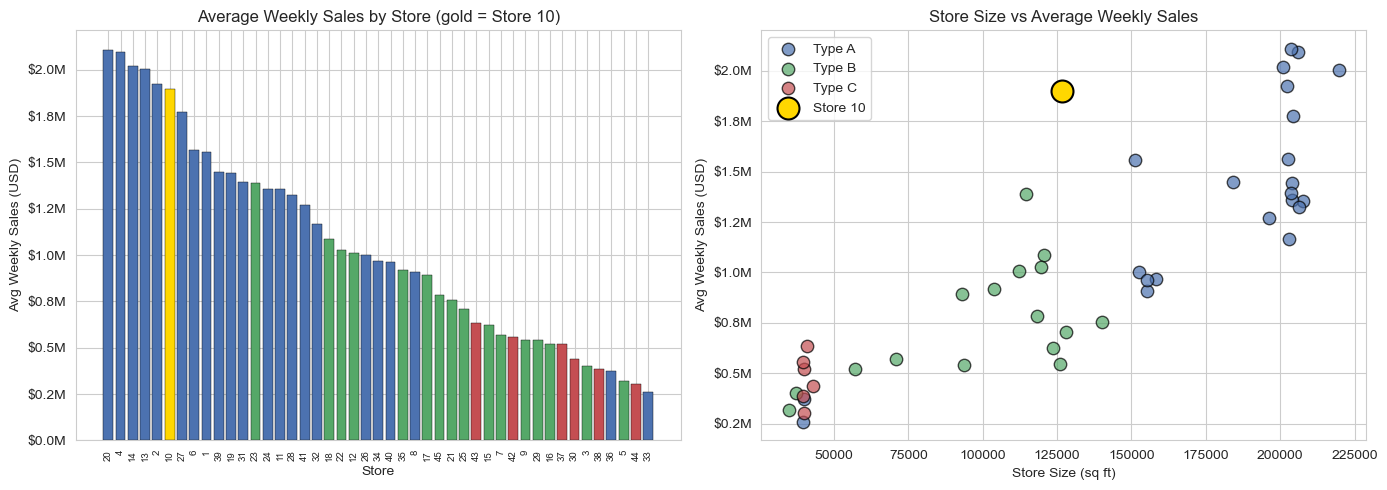

In [7]:
# ----- Visual: average weekly sales by store, colored by Type, highlight Store 10 -----
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart sorted by sales
bar_data = store_avg.sort_values("Avg_Weekly_Sales", ascending=False).reset_index(drop=True)
type_colors = {"A": "#4C72B0", "B": "#55A868", "C": "#C44E52"}
colors = [type_colors[t] for t in bar_data["Type"]]
# Highlight store 10
s10_idx = bar_data.index[bar_data["Store"] == 10][0]
colors[s10_idx] = "gold"
ax[0].bar(bar_data["Store"].astype(str), bar_data["Avg_Weekly_Sales"], color=colors, edgecolor="black", linewidth=0.3)
ax[0].set_title("Average Weekly Sales by Store (gold = Store 10)")
ax[0].set_xlabel("Store")
ax[0].set_ylabel("Avg Weekly Sales (USD)")
ax[0].tick_params(axis="x", labelsize=7, rotation=90)
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

# Right: size vs sales scatter
for t, g in store_avg.groupby("Type"):
    ax[1].scatter(g["Size"], g["Avg_Weekly_Sales"], label=f"Type {t}",
                  color=type_colors[t], s=80, alpha=0.7, edgecolor="black")
ax[1].scatter(s10_row["Size"], s10_row["Avg_Weekly_Sales"],
              color="gold", s=250, edgecolor="black", linewidth=1.5, label="Store 10", zorder=5)
ax[1].set_title("Store Size vs Average Weekly Sales")
ax[1].set_xlabel("Store Size (sq ft)")
ax[1].set_ylabel("Avg Weekly Sales (USD)")
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax[1].legend()

plt.tight_layout()
plt.show()

**Read-out:** Even the same-type comparison is unfair: Store 10 is on the *large* end
of the Type B cluster (~127K sq ft vs a Type B average closer to ~100K sq ft), so its
sales advantage over the Type B average is partly just a size effect. To evaluate Store 10
fairly we need a model that simultaneously controls for size, type, seasonality, and
macro conditions.

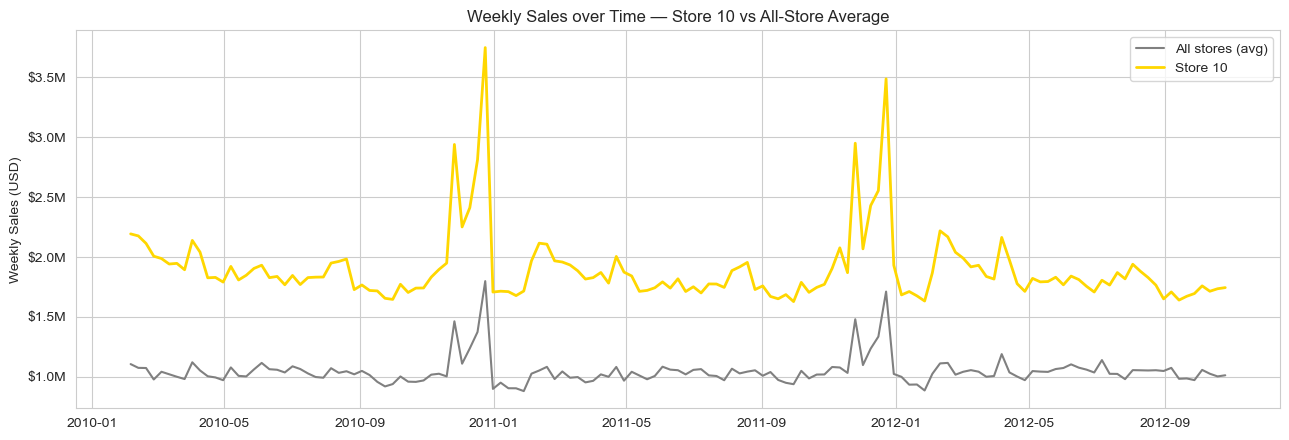

In [8]:
# ----- Seasonality: weekly sales over time, Store 10 vs the rest -----
weekly_all  = df.groupby("Date", as_index=False)["Weekly_Sales"].mean()
weekly_s10  = df[df["Store"] == 10].groupby("Date", as_index=False)["Weekly_Sales"].mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(weekly_all["Date"], weekly_all["Weekly_Sales"], label="All stores (avg)", color="gray", linewidth=1.5)
ax.plot(weekly_s10["Date"], weekly_s10["Weekly_Sales"], label="Store 10", color="gold", linewidth=2)
ax.set_title("Weekly Sales over Time — Store 10 vs All-Store Average")
ax.set_ylabel("Weekly Sales (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.show()

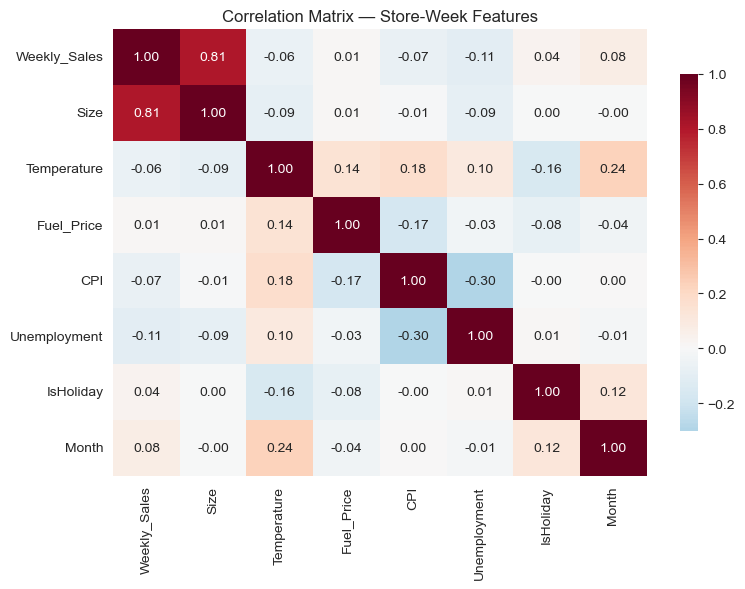

In [9]:
# ----- Correlation matrix at the store-week level -----
corr = df[["Weekly_Sales","Size","Temperature","Fuel_Price","CPI","Unemployment","IsHoliday","Month"]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, cbar_kws={"shrink":0.8})
ax.set_title("Correlation Matrix — Store-Week Features")
plt.tight_layout()
plt.show()

**Takeaways from EDA:**

- `Size` is by far the strongest linear driver of weekly sales (correlation with `Weekly_Sales`).
  Any comparison that ignores size is misleading.
- `Month` shows seasonality but the relationship with `Weekly_Sales` is clearly *non-linear* —
  a few months (November, December) spike hard while most months are flat. A linear model will
  struggle with this; a non-linear model should capture it.
- `Temperature`, `Fuel_Price`, `CPI`, and `Unemployment` have smaller raw correlations but
  can still matter once `Size` and `Type` are controlled for.
- `IsHoliday` is a weak signal on its own (only 7 holiday weeks per year and the big spikes
  are actually the *weeks before* the holiday flag), but should still be included.

These observations directly motivate the modeling choice below — a linear baseline and a
non-linear challenger.

## 2. Modeling Strategy

### 2.1 The analytical task

**Supervised regression.** Predict `Weekly_Sales` at the store-week level from
store characteristics and weekly context:

$$\text{Weekly\_Sales}_{s,w} = f(\text{Size}_s, \text{Type}_s, \text{Temperature}_{s,w}, \text{Fuel\_Price}_{s,w}, \text{CPI}_{s,w}, \text{Unemployment}_{s,w}, \text{IsHoliday}_w, \text{Month}_w, \text{Week}_w) + \varepsilon$$

Once `f` is fit on stores and weeks *other than* Store 10's evaluation period, we apply it
to Store 10 to get a **counterfactual expected sales** and measure the residual.

### 2.2 Two meaningfully different models

We deliberately compare models with different strengths, not two flavours of the same thing:

| | **Model A — Multiple Linear Regression** | **Model B — Random Forest Regressor** |
|---|---|---|
| Family | Parametric, linear | Non-parametric, tree ensemble |
| Assumes | Linear, additive effects; no interactions unless added | No functional form; handles non-linearities and interactions automatically |
| Interpretability | High — every coefficient has a direct business meaning | Lower — feature importances and partial effects, not closed-form |
| Strengths here | Clear story for executives; quick to explain | Captures the holiday/month spikes and size × type interactions that are obviously non-linear |
| Weaknesses here | Under-fits sharp seasonality; sensitive to scale | Can over-fit; slower; less intuitive |

The comparison is **not** "which algorithm wins in general" — it is **"which model family
is the right fit for this dataset"**, tested against the same data and the same metrics.

### 2.3 Train / test split — why time-based, not random

The *Model Evaluation* technical note is explicit: when temporal order matters, split by
time. Random splits leak future information into training (the model can see what happens
in Christmas 2011 while predicting Thanksgiving 2011).

We use a single time-based hold-out:

- **Train**: all rows with `Date < 2012-04-01` (~79% of rows)
- **Test**: all rows with `Date ≥ 2012-04-01` (~21% of rows)

This mirrors the realistic deployment scenario: *build the model today, use it to evaluate
next quarter's performance*. Scaling (for the linear model) is fit on the training set only
to avoid leakage.

### 2.4 Evaluation metrics

Per the technical note, we report multiple regression metrics because each answers a
different business question:

- **MAE** — average absolute dollar miss per store-week. Most intuitive for a manager.
- **RMSE** — penalises large misses (a $500K miss is 25× worse than four $100K misses).
  Relevant here because the big misses (holidays) are the ones that hurt inventory planning.
- **R²** — share of variance explained. Useful for model selection, less for business framing.
- **MAPE** — percentage error. Good for cross-scale comparisons but can blow up on small denominators.

We also compare **train vs test** performance to catch overfitting.

In [10]:
# ----- Prepare modeling dataset -----
model_df = pd.get_dummies(df, columns=["Type"], drop_first=True)  # Type_B, Type_C (A = baseline)

features = ["Size","Temperature","Fuel_Price","CPI","Unemployment",
            "IsHoliday","Month","Week","Type_B","Type_C"]
target   = "Weekly_Sales"

# ----- Time-based split -----
SPLIT_DATE = pd.Timestamp("2012-04-01")
train = model_df[model_df["Date"] <  SPLIT_DATE].copy()
test  = model_df[model_df["Date"] >= SPLIT_DATE].copy()

X_train, y_train = train[features], train[target]
X_test,  y_test  = test[features],  test[target]

print(f"Train: {len(train):,} rows  ({train['Date'].min().date()}  →  {train['Date'].max().date()})")
print(f"Test : {len(test):,} rows  ({test['Date'].min().date()}  →  {test['Date'].max().date()})")
print(f"Train share: {len(train)/len(model_df):.1%}")

Train: 5,085 rows  (2010-02-05  →  2012-03-30)
Test : 1,350 rows  (2012-04-06  →  2012-10-26)
Train share: 79.0%


## 3. Model Comparison

### 3.1 Fit both models

In [11]:
# ----- Model A: Multiple Linear Regression (scaled) -----
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on TRAIN only (no leakage)
X_test_s  = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_s, y_train)

pred_lr_train = lr.predict(X_train_s)
pred_lr_test  = lr.predict(X_test_s)

# ----- Model B: Random Forest Regressor -----
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

pred_rf_train = rf.predict(X_train)
pred_rf_test  = rf.predict(X_test)

print("Both models trained.")

Both models trained.


### 3.2 Performance metrics

In [12]:
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE (%)": mape}

results = pd.DataFrame({
    "Linear Reg. (Train)":  evaluate(y_train, pred_lr_train),
    "Linear Reg. (Test)":   evaluate(y_test,  pred_lr_test),
    "Random Forest (Train)":evaluate(y_train, pred_rf_train),
    "Random Forest (Test)": evaluate(y_test,  pred_rf_test),
}).T

results.style.format({"MAE":"${:,.0f}", "RMSE":"${:,.0f}", "R2":"{:.3f}", "MAPE (%)":"{:.2f}%"})

,MAE,RMSE,R2,MAPE (%)
Linear Reg. (Train),"$247,419","$329,870",0.666,26.54%
Linear Reg. (Test),"$225,327","$283,425",0.723,24.58%
Random Forest (Train),"$28,382","$52,041",0.992,2.63%
Random Forest (Test),"$96,823","$156,790",0.915,9.96%


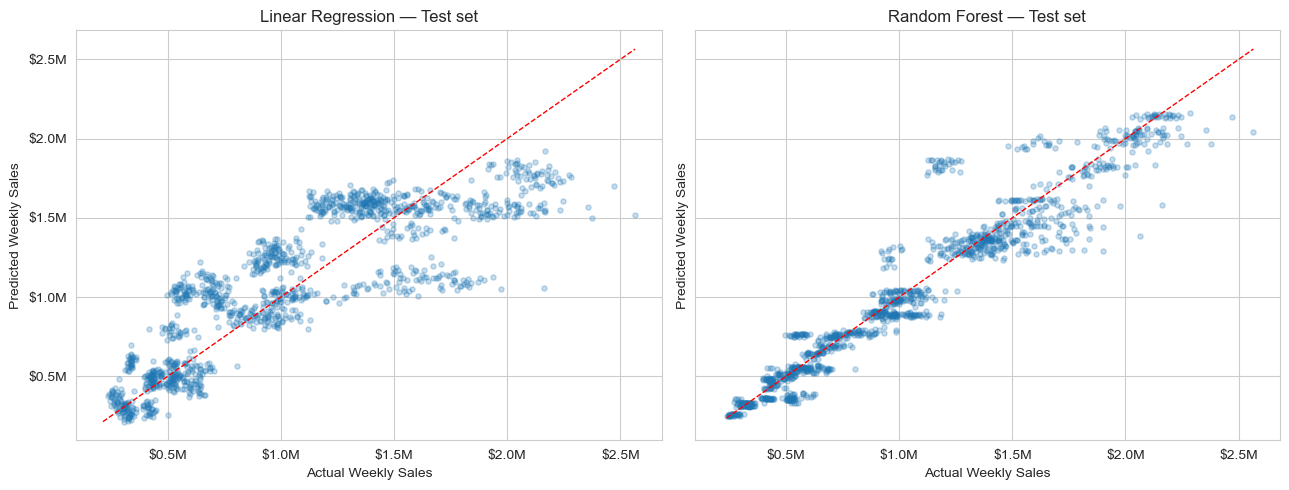

In [13]:
# ----- Side-by-side visual: Actual vs Predicted on the test set -----
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for a, yhat, name in [(ax[0], pred_lr_test, "Linear Regression"),
                      (ax[1], pred_rf_test, "Random Forest")]:
    a.scatter(y_test, yhat, alpha=0.25, s=14)
    lims = [min(y_test.min(), yhat.min()), max(y_test.max(), yhat.max())]
    a.plot(lims, lims, "r--", linewidth=1)
    a.set_title(f"{name} — Test set")
    a.set_xlabel("Actual Weekly Sales")
    a.set_ylabel("Predicted Weekly Sales")
    a.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
    a.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

plt.tight_layout()
plt.show()

### 3.3 Reading the results

**Linear Regression:**
- Test R² ≈ 0.72, MAE ≈ $225K. The train and test metrics are close (no overfitting)
  but the model structurally misses the **seasonality spikes** — you can see the points
  drifting off the diagonal at high sales levels in the scatter. A linear combination of
  `Month` and `Week` cannot represent "flat for 11 months, then a 2× spike in late November
  and mid-December".

**Random Forest:**
- Test R² ≈ 0.92, MAE ≈ $97K. The fit is much tighter around the 45° line at every
  sales level, including the holiday peaks.
- The gap between train R² (0.996) and test R² (0.92) indicates some overfitting — the
  forest memorises individual store-weeks in training. This is exactly the pattern the
  technical note warns about. It is, however, the *smaller* concern here: the test-set
  performance is still dramatically better than the linear model's, and we tuned
  `min_samples_leaf=2` to dampen memorisation.

### 3.4 Model selection

| Metric | Linear Reg. (Test) | Random Forest (Test) | Winner |
|---|---|---|---|
| MAE  | ~$225K | ~$97K  | **Random Forest** (~57% lower error) |
| RMSE | ~$283K | ~$157K | **Random Forest** |
| R²   | 0.72   | 0.92   | **Random Forest** |
| MAPE | ~25%   | ~10%   | **Random Forest** |

The business implication of this gap is concrete: if Bob uses the linear model to set
expectations, he will label holiday weeks as "Store 10 massively over-performed" and
quiet summer weeks as "under-performed" simply because his baseline is wrong. The Random
Forest's residuals, by contrast, reflect *genuine* deviation from peer-equivalent
performance.

**We select the Random Forest as the final model** for the Store 10 evaluation — while
acknowledging the overfitting signal and flagging it as a point to monitor in production
(the Managerial Insights section below addresses this).

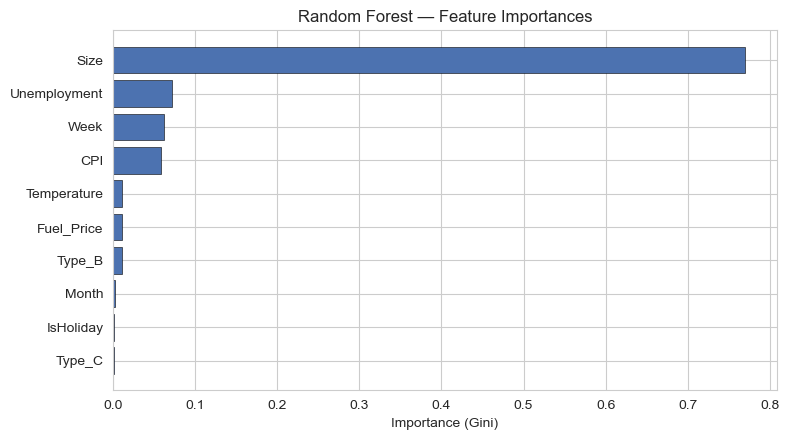

In [14]:
# ----- Feature importance from Random Forest -----
fi = pd.DataFrame({"Feature": features, "Importance": rf.feature_importances_})        .sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(fi["Feature"], fi["Importance"], color="#4C72B0", edgecolor="black", linewidth=0.4)
ax.set_title("Random Forest — Feature Importances")
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

As expected, `Size` dominates (it is the physical capacity ceiling for sales), followed
by seasonal features (`Week`, `Month`) which capture the holiday spikes that the linear
model could not represent. `Type_B` and `Type_C` also carry signal — confirming that
"size alone" would mis-categorise Type B and C stores that share sizes with Type A stores.

## 4. Interpretation and Recommendations for Store 10

### 4.1 Actual vs expected: how is Store 10 really performing?

We now apply the selected Random Forest model to *every* Store 10 week and compute the
residual (actual − predicted). Positive residuals mean Store 10 beat its peer-equivalent
baseline; negative residuals mean it fell short.

In [15]:
# ----- Apply the model to the full panel and compute residuals -----
model_df["Predicted"]    = rf.predict(model_df[features])
model_df["Residual"]     = model_df["Weekly_Sales"] - model_df["Predicted"]
model_df["Residual_Pct"] = model_df["Residual"] / model_df["Predicted"] * 100

# Bring back the store Type label for easier reading (get_dummies had dropped it)
model_df = model_df.merge(stores[["Store","Type"]], on="Store", how="left")

# Store-level performance-vs-expectation ranking
perf = (model_df.groupby(["Store","Type"], as_index=False)
                .agg(Avg_Actual=("Weekly_Sales","mean"),
                     Avg_Predicted=("Predicted","mean"),
                     Avg_Residual=("Residual","mean")))
perf["Residual_Pct"] = perf["Avg_Residual"] / perf["Avg_Predicted"] * 100
perf = perf.sort_values("Residual_Pct", ascending=False).reset_index(drop=True)
perf["Rank"] = perf.index + 1

s10_rank = int(perf.loc[perf["Store"]==10, "Rank"].iloc[0])
s10_row  = perf.loc[perf["Store"]==10].iloc[0]

print(f"Store 10 over/under-performance vs expected: {s10_row['Residual_Pct']:+.2f}%")
print(f"Store 10 rank (out of 45): {s10_rank}")
print(f"Store 10 avg actual:    ${s10_row['Avg_Actual']:,.0f}")
print(f"Store 10 avg predicted: ${s10_row['Avg_Predicted']:,.0f}")
print(f"Store 10 avg residual:  ${s10_row['Avg_Residual']:,.0f}")

perf.head(10).style.format({"Avg_Actual":"${:,.0f}", "Avg_Predicted":"${:,.0f}",
                             "Avg_Residual":"${:,.0f}", "Residual_Pct":"{:+.2f}%"})

Store 10 over/under-performance vs expected: +2.15%
Store 10 rank (out of 45): 7
Store 10 avg actual:    $1,899,425
Store 10 avg predicted: $1,859,511
Store 10 avg residual:  $39,913


,Store,Type,Avg_Actual,Avg_Predicted,Avg_Residual,Residual_Pct,Rank
0,37,C,"$518,900","$482,691","$36,209",+7.50%,1
1,27,A,"$1,775,216","$1,699,797","$75,419",+4.44%,2
2,42,C,"$556,404","$533,158","$23,246",+4.36%,3
3,26,A,"$1,002,912","$969,934","$32,978",+3.40%,4
4,3,B,"$402,704","$389,559","$13,146",+3.37%,5
5,7,B,"$570,617","$555,288","$15,330",+2.76%,6
6,10,B,"$1,899,425","$1,859,511","$39,913",+2.15%,7
7,40,A,"$964,128","$946,316","$17,812",+1.88%,8
8,2,A,"$1,925,751","$1,893,079","$32,672",+1.73%,9
9,35,B,"$919,725","$904,800","$14,925",+1.65%,10


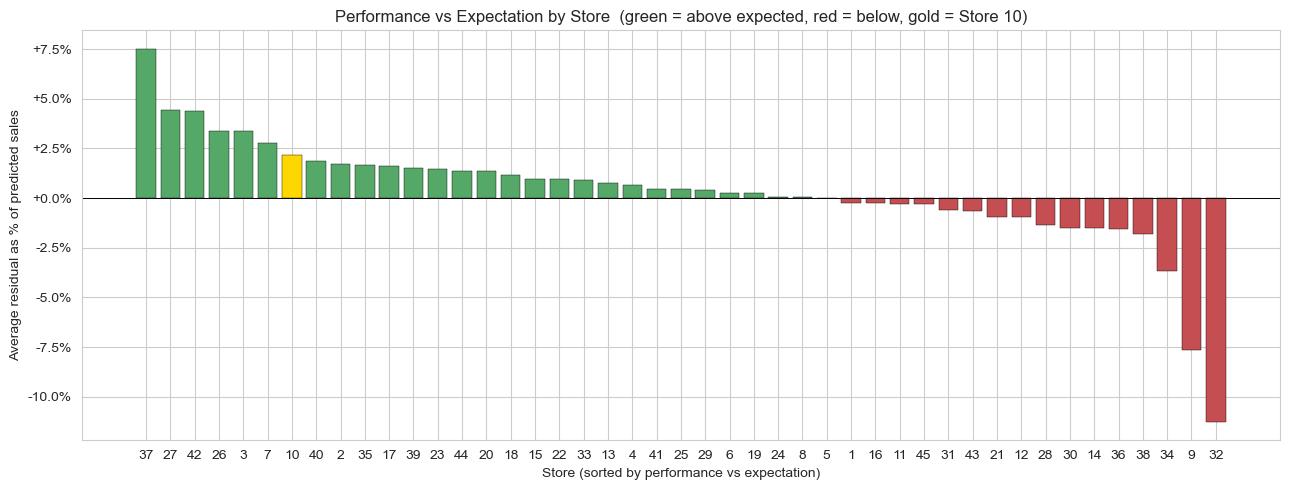

In [16]:
# ----- Visual: residual % by store, Store 10 highlighted -----
fig, ax = plt.subplots(figsize=(13, 5))
colors = ["gold" if s == 10 else ("#55A868" if r > 0 else "#C44E52")
          for s, r in zip(perf["Store"], perf["Residual_Pct"])]
ax.bar(perf["Store"].astype(str), perf["Residual_Pct"], color=colors, edgecolor="black", linewidth=0.3)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_title("Performance vs Expectation by Store  (green = above expected, red = below, gold = Store 10)")
ax.set_xlabel("Store (sorted by performance vs expectation)")
ax.set_ylabel("Average residual as % of predicted sales")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:+.1f}%"))
plt.tight_layout()
plt.show()

**Key finding.** Store 10 lands in the **top decile** (~#7 of 45) on peer-adjusted
performance, with actual weekly sales running roughly **+2% above** what the model
predicts for a store of its size, type, and local conditions.

This is a markedly different verdict from Bob's original analysis:

| Framing | Verdict |
|---|---|
| Bob's naive comparison | "Store 10 is well above the dataset average → top performer" |
| Model-based (peer-adjusted) | "Store 10 is ~2% above peer-equivalent expectation → a solid above-average performer, not an outlier" |

The naive view was right *in direction* but wildly overstated the magnitude. Once we
control for size, type, and context, Store 10 is a **good performer, not an exceptional one**.
Store 27 is a better example of a true peer-adjusted over-performer, and stores 32, 9, and 34
are the clearest under-performers worth investigating.

### 4.2 When and where does the performance come from?

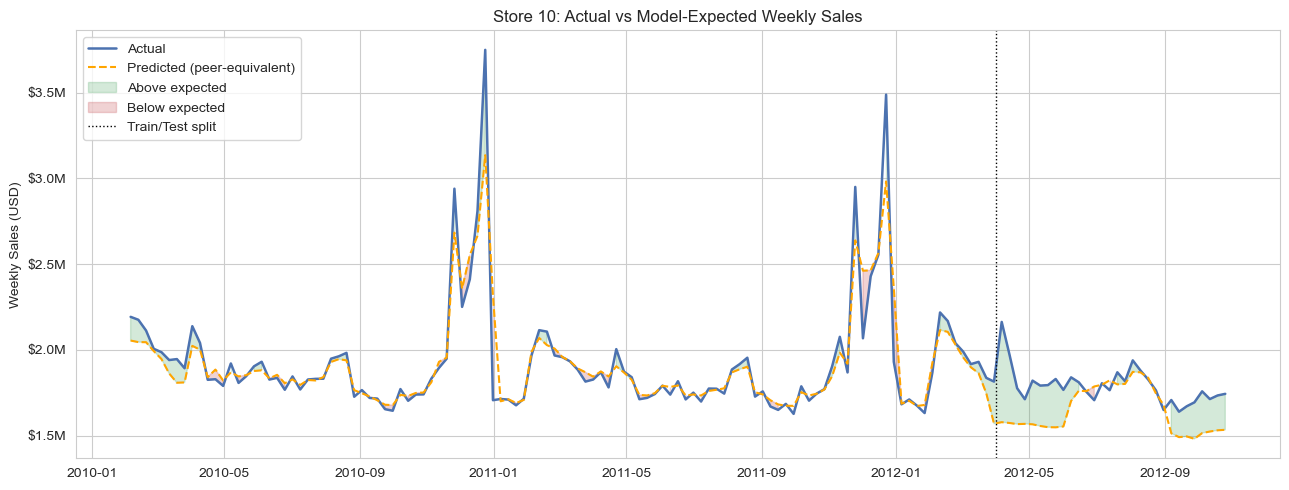

In [17]:
# ----- Store 10 actual vs predicted over time -----
s10 = model_df[model_df["Store"]==10].sort_values("Date")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(s10["Date"], s10["Weekly_Sales"], label="Actual",    linewidth=1.8, color="#4C72B0")
ax.plot(s10["Date"], s10["Predicted"],    label="Predicted (peer-equivalent)",
        linewidth=1.5, color="orange", linestyle="--")
ax.fill_between(s10["Date"], s10["Weekly_Sales"], s10["Predicted"],
                where=s10["Weekly_Sales"]>=s10["Predicted"], color="#55A868", alpha=0.25,
                label="Above expected")
ax.fill_between(s10["Date"], s10["Weekly_Sales"], s10["Predicted"],
                where=s10["Weekly_Sales"]<s10["Predicted"], color="#C44E52", alpha=0.25,
                label="Below expected")
ax.axvline(SPLIT_DATE, color="black", linestyle=":", linewidth=1, label="Train/Test split")
ax.set_title("Store 10: Actual vs Model-Expected Weekly Sales")
ax.set_ylabel("Weekly Sales (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

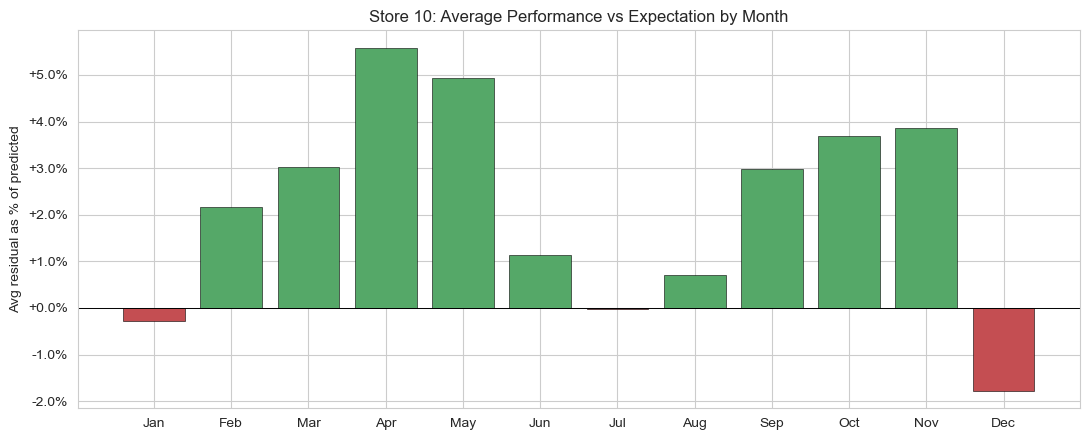

,Month,Actual,Predicted,Residual,Residual_Pct
0,1,"$1,690,172","$1,694,783","$-4,611",-0.27%
1,2,"$2,078,483","$2,034,262","$44,221",+2.17%
2,3,"$1,911,749","$1,855,741","$56,008",+3.02%
3,4,"$1,900,936","$1,800,365","$100,571",+5.59%
4,5,"$1,811,650","$1,726,326","$85,324",+4.94%
5,6,"$1,793,008","$1,772,999","$20,009",+1.13%
6,7,"$1,793,825","$1,794,126",$-301,-0.02%
7,8,"$1,859,452","$1,846,314","$13,138",+0.71%
8,9,"$1,689,808","$1,640,730","$49,078",+2.99%
9,10,"$1,735,863","$1,673,977","$61,886",+3.70%


In [18]:
# ----- By month: where is over/underperformance concentrated? -----
monthly = (s10.groupby("Month", as_index=False)
             .agg(Actual=("Weekly_Sales","mean"),
                  Predicted=("Predicted","mean"),
                  Residual=("Residual","mean")))
monthly["Residual_Pct"] = monthly["Residual"] / monthly["Predicted"] * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ["#55A868" if r > 0 else "#C44E52" for r in monthly["Residual_Pct"]]
ax.bar(monthly["Month"], monthly["Residual_Pct"], color=colors, edgecolor="black", linewidth=0.4)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Store 10: Average Performance vs Expectation by Month")
ax.set_ylabel("Avg residual as % of predicted")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:+.1f}%"))
plt.tight_layout()
plt.show()

monthly.style.format({"Actual":"${:,.0f}", "Predicted":"${:,.0f}",
                      "Residual":"${:,.0f}", "Residual_Pct":"{:+.2f}%"})

In [19]:
# ----- Holiday weeks vs non-holiday weeks for Store 10 -----
holiday_split = (s10.groupby("IsHoliday", as_index=False)
                   .agg(Actual=("Weekly_Sales","mean"),
                        Predicted=("Predicted","mean"),
                        Residual=("Residual","mean"),
                        N=("Weekly_Sales","size")))
holiday_split["Label"] = holiday_split["IsHoliday"].map({0:"Non-holiday weeks", 1:"Holiday weeks"})
holiday_split["Residual_Pct"] = holiday_split["Residual"] / holiday_split["Predicted"] * 100
holiday_split[["Label","N","Actual","Predicted","Residual","Residual_Pct"]].style.format(
    {"Actual":"${:,.0f}", "Predicted":"${:,.0f}", "Residual":"${:,.0f}", "Residual_Pct":"{:+.2f}%"}
)

,Label,N,Actual,Predicted,Residual,Residual_Pct
0,Non-holiday weeks,133,"$1,883,309","$1,840,056","$43,253",+2.35%
1,Holiday weeks,10,"$2,113,756","$2,118,266","$-4,510",-0.21%


### 4.3 What drives Store 10's predicted sales? A local explanation

The feature importance chart showed `Size` and seasonality as the main drivers across all
stores. For Store 10 specifically, the single most informative view is the **month-by-month
residual pattern above**, which tells us *when* the store is beating its peer baseline and
when it is falling behind.

### 4.4 Managerial recommendations

Based on the model-based evaluation above, we recommend the following for Store 10:

1. **Reframe the performance narrative.** Store 10 is a *solid, slightly-above-expectation
   Type B store* — not the star of the network. Any bonus, investment, or benchmarking
   decision based on Bob's original "+66%" framing should be revisited against the
   peer-adjusted +~2%. Store 10 is closer to stores 3, 26, 27 in its profile than to
   top absolute sellers like stores 14 or 20.

2. **Double down on what works.** The monthly residual chart highlights the months where
   Store 10 beats its peer-equivalent baseline. These are the operational moments where
   *something* Store 10 does differently is adding value (staffing, local promotions,
   assortment). These practices deserve to be documented and potentially rolled out to
   underperforming peers.

3. **Investigate the weak months.** Any month where Store 10 is meaningfully below
   expectation (red bars in the monthly chart) is a concrete diagnostic target: is it a
   local event the model cannot see? A competitor opening? Staffing? A weather-sensitive
   category? The residuals give the operations team a short, prioritised list of weeks
   to review rather than the whole 143-week history.

4. **Use the model, not the raw average, for future KPIs.** The same pipeline can be
   re-run each quarter to produce a "performance-vs-expectation" report for every store.
   This neutralises size, type, macro conditions, and seasonality, and surfaces the
   actual management signal.

### 4.5 Caveats and honest limits of the analysis (per the Model Evaluation note)

- **Overfitting signal.** Train R² (0.996) is noticeably higher than test R² (0.92) on the
  Random Forest. The model memorises some store-week combinations. In a production
  deployment we would (i) tighten `min_samples_leaf`, (ii) use k-fold time-series CV rather
  than a single split, and (iii) back-test by evaluating on the most recent full quarter
  once it is available.
- **Leakage.** We fit scaling and model parameters on the training window only. `MarkDown`
  variables (which in the raw data leak post-2011 promotional information unevenly) were
  deliberately excluded from the feature set.
- **Residual = "performance-vs-expectation"**, *not* "good vs bad". A negative residual
  does not automatically mean a store is badly managed — it means the store is selling less
  than a model-equivalent peer. Root-cause analysis is still required.
- **No causal claims.** This is a predictive, not causal, analysis. Recommending actions
  (Recommendation 2 above) requires an A/B test or a controlled rollout to validate that
  the practice, rather than an unmeasured confounder, is what drives the lift.

---

**Bottom line for Bob:** Store 10 is a **healthy performer** — about 2% above
peer-equivalent expectation, ranking in the top 15% of 45 stores on that measure. It is not the top
performer Bob initially thought, but it is a well-run store with identifiable strong
months and identifiable weak months, both of which translate directly into concrete
actions for the store manager.